

# Customer Churn and Revenue Insights Analysis

## Business Understanding

Customer churn is one of the biggest challenges faced by subscription-based companies. When customers stop using a service, the company loses revenue and may spend more money trying to get new customers. Understanding why customers leave is important for improving customer satisfaction and business growth.

In this project, the business is trying to identify the main factors that cause customer churn, understand which customers are most likely to leave, and find ways to reduce revenue loss. The analysis will help the company make better business decisions and improve customer retention strategies.

---

# Problem Statement

The company has been experiencing customer churn, which affects its revenue and long-term growth. However, the company does not fully understand the reasons why customers leave or which customer groups are most at risk of churning.

This project aims to analyze customer data to identify patterns, trends, and factors that contribute to churn. The findings will help the business develop strategies to improve customer retention and reduce revenue loss.

---

# Project Objectives

The main objectives of this project are:

1. To analyze customer behavior and identify churn patterns.
2. To determine the factors that influence customer churn.
3. To measure the impact of churn on company revenue.
4. To identify high-risk customers who are likely to leave.
5. To create visualizations and dashboards that communicate insights clearly.
6. To build a simple predictive model for churn prediction.

---

# Project Questions

This project seeks to answer the following questions:

* What is the overall customer churn rate?
* Which customer groups are more likely to churn?
* How does contract type affect churn?
* Does monthly cost influence customer retention?
* Which services are commonly associated with churn?
* How much revenue is lost due to churn?
* Can churn be predicted using customer data?

---

# Tools and Technologies Used

The following tools will be used in this project:

* Python (Pandas, NumPy, Matplotlib, Seaborn)
* SQL
* Tableau
* Jupyter Notebook
* Excel

---

# Expected Outcome

At the end of this project, the analysis is expected to provide useful insights into customer behavior, churn trends, and revenue impact. The findings will help the business make data-driven decisions to improve customer retention and overall performance.



## Data understanding

###  1. Importing the neccessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load and Preview the Dataset

In [2]:
# Load the Telco Customer Churn dataset
data = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows of the dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# check the size of the dataset
data.shape

(7043, 21)

The dataset contains 7,043 customer records and 21 features/columns.

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Dataset Information

The dataset contains **7,043 customer records** and **21 columns** with no missing values detected in the initial overview.

Data Type Summary
- **18 categorical columns (`str`)**
- **2 integer columns (`int64`)**
- **1 numerical decimal column (`float64`)**

Key Observations
- Most variables are categorical and describe customer demographics, services, and account information.
- `MonthlyCharges` is already stored as a numerical variable.
- `TotalCharges` is currently stored as a string (`str`) and may need to be converted to a numeric data type for analysis.
- The target variable is `Churn`, which indicates whether a customer left the company or not.


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The statistical summary shows that most customers are not senior citizens, with an average value of 0.16. Customers have stayed with the company for an average of 32 months, while monthly charges average around 64.76. The wide range in tenure and monthly charges suggests that customers have different subscription behaviors, which may influence churn.

In [6]:
data.duplicated().sum()

np.int64(0)

#### Duplicate Values Check

The output shows that the dataset contains 0 duplicate records. This means that every customer entry in the dataset is unique and there are no repeated rows.


In [7]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Missing Values Check

The output shows that all columns have 0 missing values, meaning the dataset is complete and no data is missing from any feature.



In [8]:
data["TotalCharges"]=pd.to_numeric(data["TotalCharges"], errors='coerce')

Data Type Correction: TotalCharges

The TotalCharges column is currently stored as an object (string type), even though it represents a numerical variable. This can happen when a column contains mixed formats or hidden spaces.

To ensure the column can be used for analysis, we convert it into a numeric data type.

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
data = data.dropna(subset=["TotalCharges"])

Handling Missing Values in TotalCharges

After converting the TotalCharges column to a numeric format, we identified a small number of missing values (11 rows).

Since the number of missing values is very small compared to the total dataset, we remove these rows to maintain data quality without significantly affecting the analysis.

In [12]:
data['Churn'] = data['Churn'].str.strip()


Cleaning Text Values in Churn Column

The Churn column contains categorical text values that may include hidden leading or trailing spaces. These extra spaces can cause inconsistencies when performing grouping, filtering, or analysis.

To ensure consistency, we remove any unnecessary whitespace from the values using the .str.strip() function.

## FEATURE ENGINEERING

Encoding the target variable

In [13]:
# Converting the categorical column into numerical
data["Churn"]=data['Churn'].map({'Yes':1, 'No':0})

Creating Tenure groups

In [14]:
def tenure_group (x):
    if x<=12:
        return "0-1 year"
    elif x<=24:
        return "1-2 years"
    elif x<=48:
        return "2-4 years"
    else:
        return "4+ years"
    

data["TenureGroup"]= data["tenure"].apply(tenure_group) 

In [15]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

data['TotalServices'] = (data[service_cols] == 'Yes').sum(axis=1)
data['TotalServices']

0       1
1       2
2       2
3       3
4       0
       ..
7038    5
7039    4
7040    1
7041    0
7042    5
Name: TotalServices, Length: 7032, dtype: int64

In [16]:
data['ChargeCategory'] = pd.qcut(
    data['MonthlyCharges'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)
data['ChargeCategory']

0             Low
1          Medium
2          Medium
3          Medium
4            High
          ...    
7038         High
7039    Very High
7040          Low
7041         High
7042    Very High
Name: ChargeCategory, Length: 7032, dtype: category
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Very High']

## EXPLORATORY DATA ANALYSIS (EDA)

### Univariate Analysis

Univariate analysis is used to understand the distribution of individual variables in the dataset. 

1. Churn Distribution

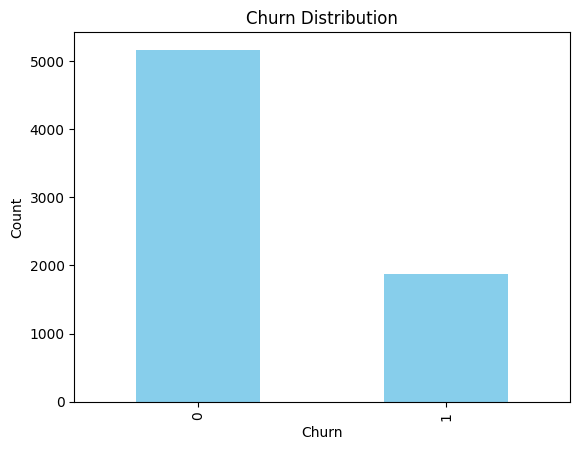

In [17]:
data['Churn'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The dataset shows that customers who did not churn are more than customers who churned. This means the company retains most of its customers, while a smaller proportion leaves the service.


2. Monthly Charges Distribution

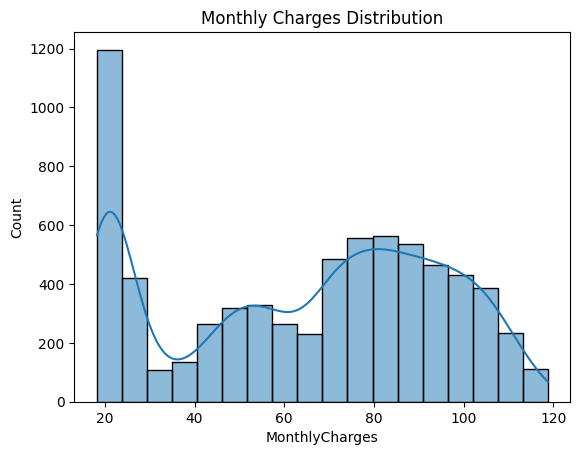

In [18]:
sns.histplot(data['MonthlyCharges'],kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

The distribution of monthly charges shows that customers are spread across different pricing levels, with noticeable concentrations around $20 and between $70 and $100 per month. This suggests that the company serves both lower-paying and higher-paying customer segments. The larger concentration of customers in the higher monthly charge range indicates that a significant portion of revenue comes from these customers. Therefore, if customers in this group churn, the company could experience a substantial loss in revenue. Further analysis is needed to determine whether customers with higher monthly charges are more likely to churn than those with lower monthly charges.


3. Tenure Distribution

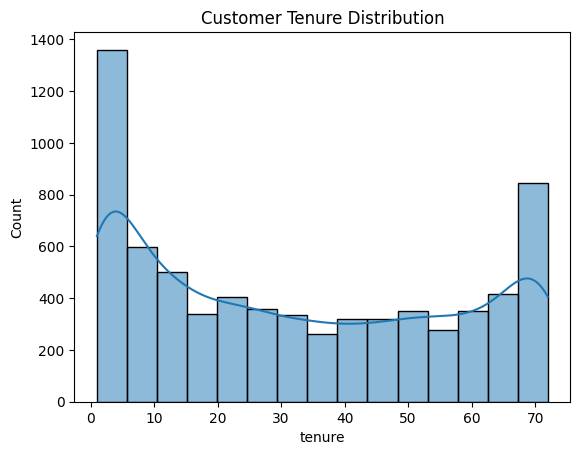

In [19]:
sns.histplot(data['tenure'], kde=True)
plt.title("Customer Tenure Distribution")
plt.show()


The distribution shows that many customers are either relatively new or have remained with the company for a long period. There are fewer customers with medium tenure lengths. This suggests that customer retention is strongest among long-term customers, while the early stages of the customer lifecycle may be critical for preventing churn.

4. Total Services Disribution

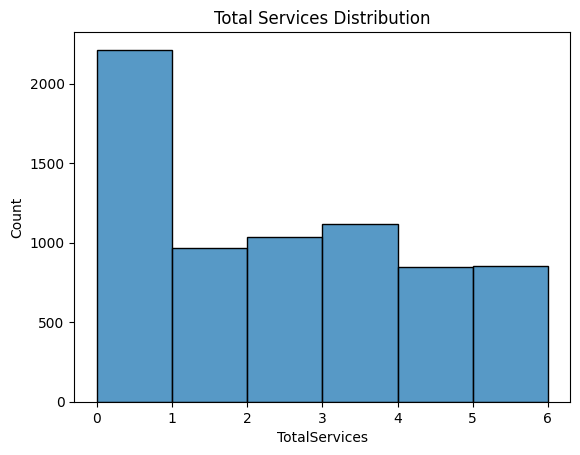

In [20]:
sns.histplot(data['TotalServices'], bins=6)
plt.title("Total Services Distribution")
plt.show()


Most customers use only 0 to 1 service, while fewer customers use multiple services. This suggests that single-service customers make up the largest customer group. 

### Bivariate Analysis

Bivariate analysis explores the relationship between churn and other customer features to identify key drivers of customer loss.

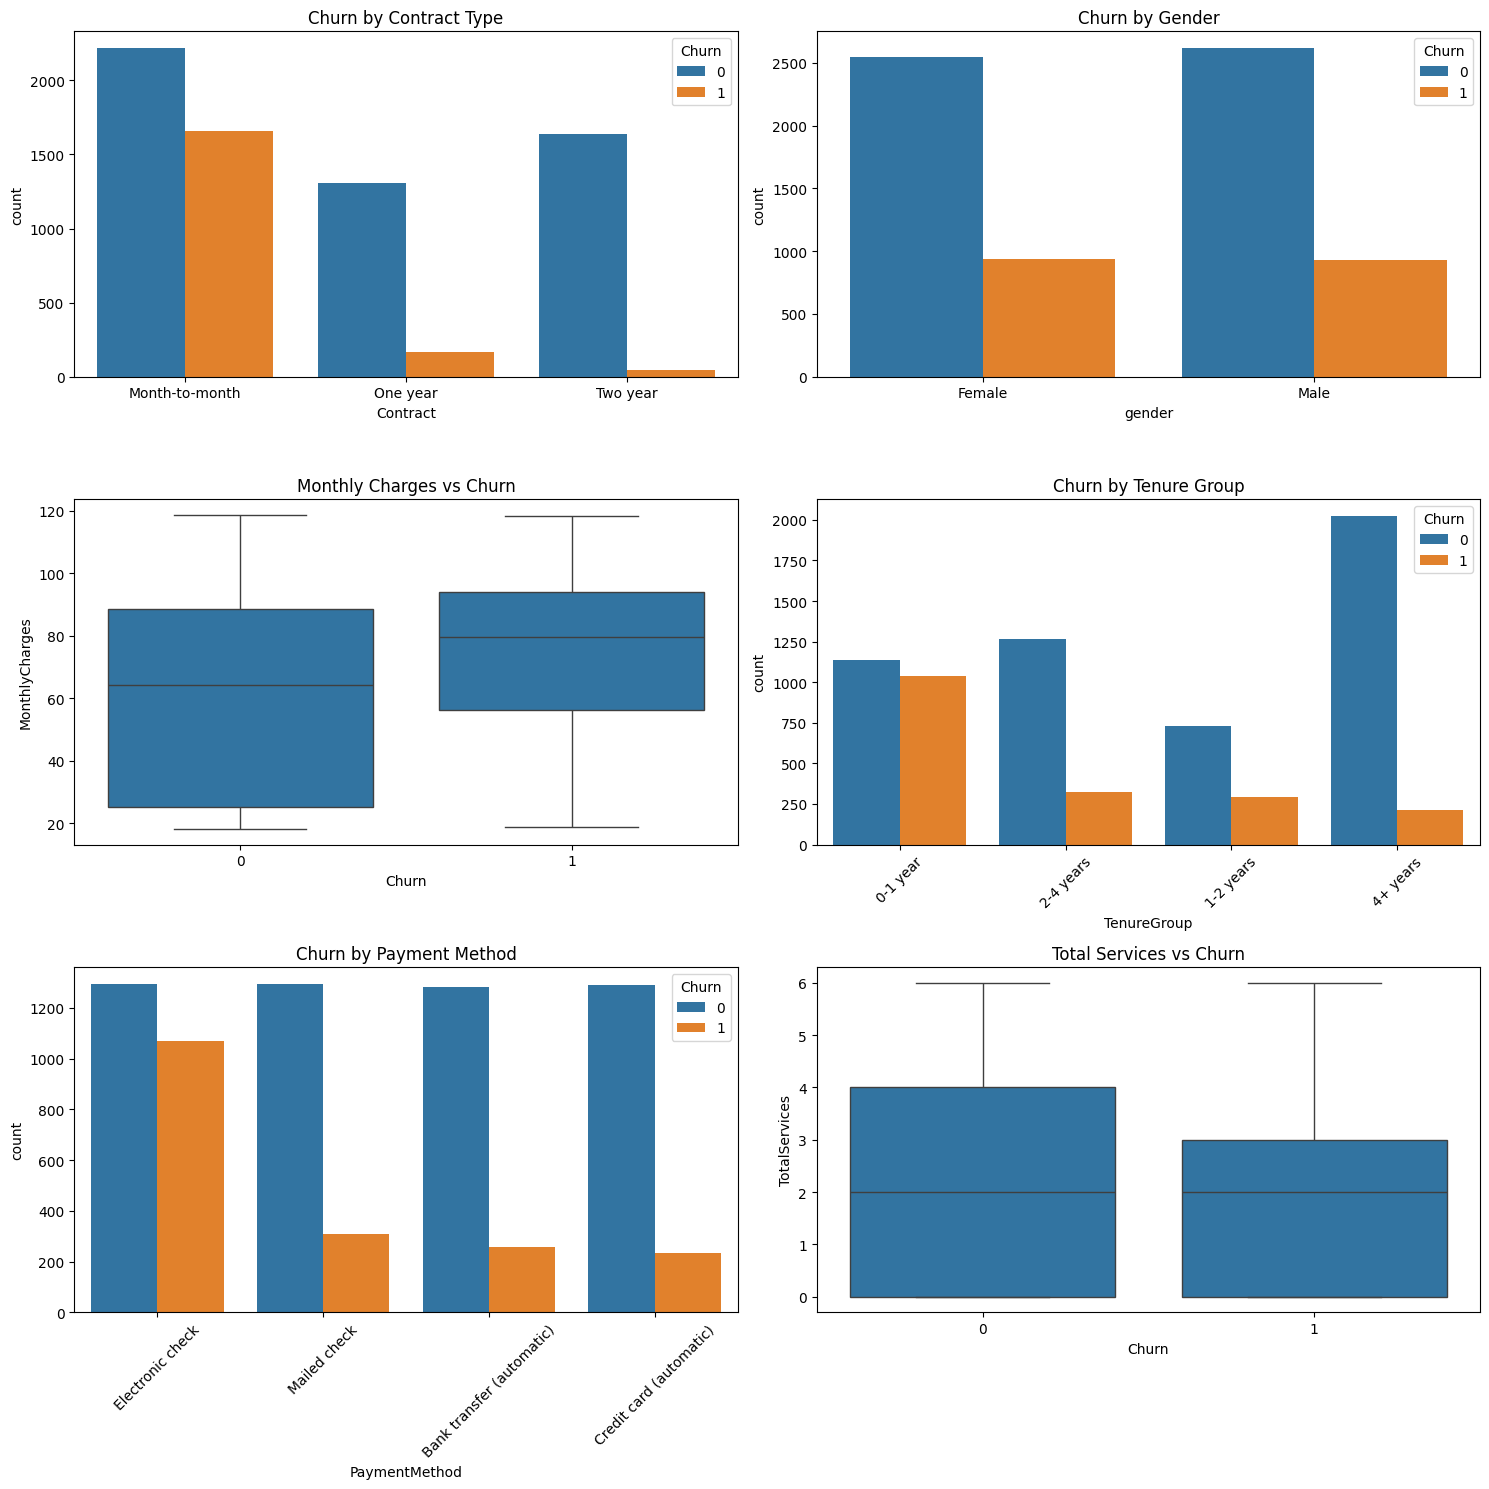

In [21]:

fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Churn vs Contract Type
sns.countplot(x='Contract', hue='Churn', data=data, ax=axes[0,0])
axes[0,0].set_title('Churn by Contract Type')

# Churn vs Gender
sns.countplot(x='gender', hue='Churn', data=data, ax=axes[0,1])
axes[0,1].set_title('Churn by Gender')

# Churn vs Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=data, ax=axes[1,0])
axes[1,0].set_title('Monthly Charges vs Churn')

# Churn vs Tenure Group
sns.countplot(x='TenureGroup', hue='Churn', data=data, ax=axes[1,1])
axes[1,1].set_title('Churn by Tenure Group')
axes[1,1].tick_params(axis='x', rotation=45)

# Churn vs Payment Method
sns.countplot(x='PaymentMethod', hue='Churn', data=data, ax=axes[2,0])
axes[2,0].set_title('Churn by Payment Method')
axes[2,0].tick_params(axis='x', rotation=45)

# Churn vs Total Services
sns.boxplot(x='Churn', y='TotalServices', data=data, ax=axes[2,1])
axes[2,1].set_title('Total Services vs Churn')

plt.tight_layout()
plt.show()

**Key Findings from Bivariate Analysis**

The analysis reveals that customer churn is strongly associated with contract type, tenure, monthly charges, and payment method. Customers on month-to-month contracts, customers with shorter tenure, and customers paying higher monthly charges are more likely to churn. Gender shows little to no relationship with churn behavior. These findings suggest that retention efforts should focus on improving the experience of new customers, encouraging long-term contracts, and evaluating pricing strategies.

### Correlation Analysis


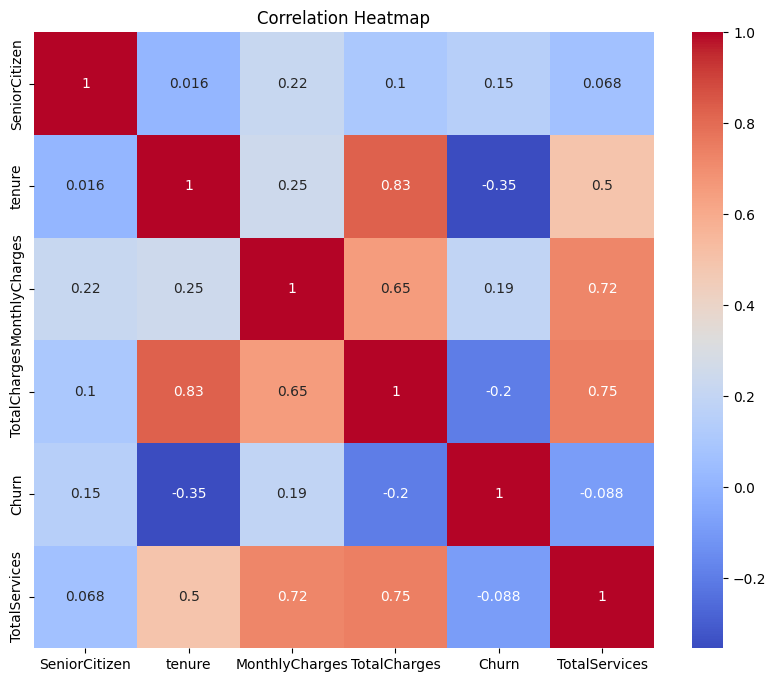

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.select_dtypes(include=['int64', 'float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap Interpretation

The correlation heatmap shows the relationship between customer features and churn.

- **Tenure** has the strongest negative correlation with churn (-0.35), meaning customers who stay longer are less likely to leave.
- **MonthlyCharges** has a positive correlation with churn (0.19), indicating that higher charges slightly increase the likelihood of churn.


### Revenue Impact Analysis

In [25]:
data.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

Customers who churned (left the company) tend to have higher monthly charges than those who stayed.

In [26]:
revenue_loss = data[data['Churn'] == 1]['MonthlyCharges'].sum()

print(f"Potential Monthly Revenue Lost: ${revenue_loss:.2f}")

Potential Monthly Revenue Lost: $139130.85


This means that every month, the company is losing about $139K from customers who leave.